<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_032_ml_pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 32/365 — Machine Learning Pipelines
## How do we make preprocessing safer and repeatable?

Yesterday we learned about **data leakage**. Today we solve one common cause of it: preprocessing being fitted on the wrong data.

A scikit-learn **Pipeline** lets us chain missing-value imputation, feature scaling, and model training into one object.

For this experiment we use the real **Diabetes regression dataset**, deliberately add some missing values, and compare a correct manual workflow with a Pipeline-based workflow.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score


## 1. Load the real dataset


In [2]:
diabetes = load_diabetes(as_frame=True)
X = diabetes.data.copy()
y = diabetes.target.copy()
print('Dataset shape:', X.shape)
display(X.head())


Dataset shape: (442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## 2. Add controlled missing values

The original dataset is complete, so we deliberately hide some values in a few columns for learning.


In [3]:
rng = np.random.default_rng(42)
X_missing = X.copy()
for col in ['bmi', 'bp', 's1']:
    mask = rng.random(len(X_missing)) < 0.10
    X_missing.loc[mask, col] = np.nan
print(X_missing.isna().sum())


age     0
sex     0
bmi    41
bp     47
s1     38
s2      0
s3      0
s4      0
s5      0
s6      0
dtype: int64


## 3. Split the data


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_missing, y, test_size=0.20, random_state=42
)


## 4. Correct manual preprocessing

We must fit the imputer on training data, transform train/test, fit the scaler on training data, transform again, then train the model.


In [5]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

manual_model = Ridge(alpha=1.0)
manual_model.fit(X_train_scaled, y_train)
manual_pred = manual_model.predict(X_test_scaled)

manual_rmse = np.sqrt(mean_squared_error(y_test, manual_pred))
manual_r2 = r2_score(y_test, manual_pred)

print('Manual RMSE:', round(manual_rmse, 2))
print('Manual R2:', round(manual_r2, 3))


Manual RMSE: 55.88
Manual R2: 0.411


## 5. The same workflow with a Pipeline

The Pipeline keeps preprocessing and the model together, so each step is fitted in the correct sequence.


In [6]:
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline.fit(X_train, y_train)
pipeline_pred = pipeline.predict(X_test)

pipeline_rmse = np.sqrt(mean_squared_error(y_test, pipeline_pred))
pipeline_r2 = r2_score(y_test, pipeline_pred)

print('Pipeline RMSE:', round(pipeline_rmse, 2))
print('Pipeline R2:', round(pipeline_r2, 3))


Pipeline RMSE: 55.88
Pipeline R2: 0.411


## 6. Compare manual vs Pipeline


In [7]:
comparison = pd.DataFrame({
    'Workflow': ['Correct Manual Workflow', 'Pipeline'],
    'Test RMSE': [manual_rmse, pipeline_rmse],
    'Test R2': [manual_r2, pipeline_r2]
})
display(comparison.round(4))


,Workflow,Test RMSE,Test R2
0,Correct Manual Workflow,55.8771,0.4107
1,Pipeline,55.8771,0.4107


## 7. Pipeline + cross-validation

During each fold, the imputer and scaler must be fitted only on that fold's training portion. Putting them inside the Pipeline makes this automatic.


In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse = -cross_val_score(
    pipeline,
    X_missing,
    y,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

print('RMSE by fold:', np.round(cv_rmse, 2))
print('Mean CV RMSE:', round(cv_rmse.mean(), 2))
print('Std CV RMSE:', round(cv_rmse.std(), 2))


RMSE by fold: [55.88 54.37 58.51 54.47 58.65]
Mean CV RMSE: 56.38
Std CV RMSE: 1.88


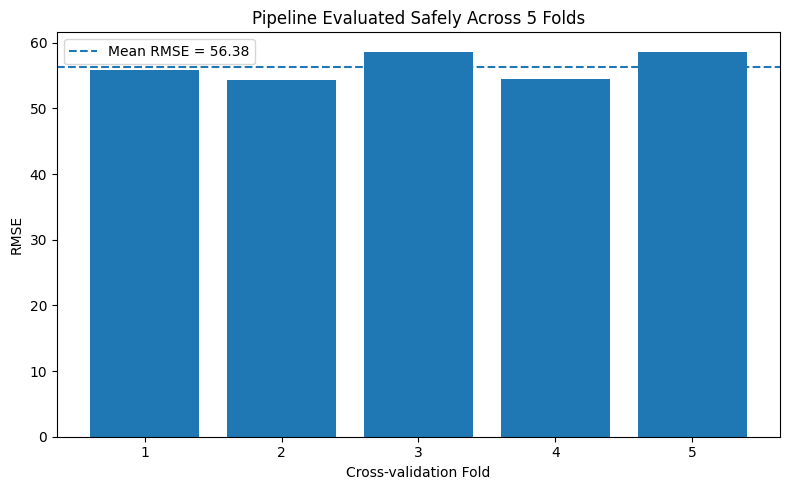

In [9]:
folds = np.arange(1, 6)
plt.figure(figsize=(8, 5))
plt.bar(folds, cv_rmse)
plt.axhline(cv_rmse.mean(), linestyle='--', label=f'Mean RMSE = {cv_rmse.mean():.2f}')
plt.xlabel('Cross-validation Fold')
plt.ylabel('RMSE')
plt.title('Pipeline Evaluated Safely Across 5 Folds')
plt.xticks(folds)
plt.legend()
plt.tight_layout()
plt.show()


## What does this experiment teach?

- A Pipeline does **not** automatically make a model more accurate.
- It packages preprocessing and modelling into one repeatable workflow.
- During cross-validation, preprocessing is re-fitted inside each fold.
- This reduces accidental train/test contamination.
- Pipelines also make deployment safer because the same transformations travel with the model.

> **Preprocessing is part of the model pipeline, not a separate one-time cleaning step.**


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- https://scikit-learn.org/stable/modules/compose.html#pipeline
- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html
